# Optimize σz with Jx(t) Fourier (black-box SciPy)


In [2]:
import numpy as np
from scipy.linalg import lu_factor, lu_solve

# ---- Pauli operators + basic utilities ----
I2 = np.array([[1., 0.], [0., 1.]], dtype=complex)
sx = np.array([[0., 1.], [1., 0.]], dtype=complex)
sy = np.array([[0., -1j], [1j, 0.]], dtype=complex)
sz = np.array([[1., 0.], [0., -1.]], dtype=complex)
sigma_minus = np.array([[0., 1.], [0., 0.]], dtype=complex)  # |0><1|

def vec(A: np.ndarray) -> np.ndarray:
    """Column-stacking vec (Fortran order)."""
    return np.asarray(A, dtype=complex).reshape(-1, order="F")

def mat(v: np.ndarray) -> np.ndarray:
    """Inverse of vec for 2x2 matrices."""
    return np.asarray(v, dtype=complex).reshape((2, 2), order="F")

def trace_vec() -> np.ndarray:
    """Vector such that Tr(rho) = trace_vec()^T vec(rho)."""
    return vec(I2)

def random_density(rng: np.random.Generator) -> np.ndarray:
    """Random physical single-qubit density matrix (Hilbert-Schmidt)."""
    A = rng.standard_normal((2, 2)) + 1j * rng.standard_normal((2, 2))
    rho = A @ A.conj().T
    rho = rho / np.trace(rho)
    return rho

# ---- Fourier basis over normalized time s=t/T ----
def basis_matrix(s_nodes: np.ndarray, M: int) -> np.ndarray:
    """B[j,:]=[cos(2π*1*s_j)..cos(2π*M*s_j), sin(2π*1*s_j)..sin(2π*M*s_j)]."""
    m = np.arange(1, M + 1).reshape(1, -1)
    ang = 2 * np.pi * s_nodes.reshape(-1, 1) * m
    C = np.cos(ang)
    S = np.sin(ang)
    return np.hstack([C, S])  # (N, 2M)

# ---- NESS fixed-point solve (works for any 4x4 Floquet map Phi you build) ----
def ness_augmented_system(Phi: np.ndarray):
    """
    Solve r* = Phi r* with Tr(rho)=1 using an augmented linear system:
      [I-Phi, c] [r*]   [0]
      [c^T , 0] [λ ] = [1]
    where c = vec(I).
    """
    n = Phi.shape[0]
    c = trace_vec().reshape(-1, 1)
    A = np.block([
        [np.eye(n, dtype=complex) - Phi, c],
        [c.T, np.zeros((1, 1), dtype=complex)]
    ])
    b = np.zeros((n + 1,), dtype=complex)
    b[-1] = 1.0
    return A, b

In [ ]:
import os, time, json
import numpy as np
from scipy.optimize import minimize
from pathlib import Path

import qutip as qt
from scipy.linalg import lu_factor, lu_solve


def sanitize_for_json(obj):
    import numpy as _np
    if isinstance(obj, _np.ndarray):
        return obj.tolist()
    if isinstance(obj, (_np.integer, _np.floating, _np.bool_)):
        return obj.item()
    if isinstance(obj, (_np.complexfloating, complex)):
        c = complex(obj)
        return [float(c.real), float(c.imag)]
    if isinstance(obj, dict):
        return {k: sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize_for_json(v) for v in obj]
    return obj


# --- parameters (as requested) ---
gamma_down = 4.7
gamma_phi  = 0.3

# N is NOT used to build propagators anymore. We keep it only for
# sampling micromotion + consistent plot workflow.
N = 48
M = 3

thetaJ_bounds = 50.0
T_bounds = (0.05, 2.0)

seed = 1
n_restarts = 6
maxiter = 250
fd_eps = 1e-6

rng = np.random.default_rng(seed)

p = 2 * M
bounds = [(-thetaJ_bounds, thetaJ_bounds)] * p + [T_bounds]

# --- QuTiP operators (2-level system) ---
sx_q = qt.Qobj(sx)
sy_q = qt.Qobj(sy)
sz_q = qt.Qobj(sz)
sm_q = qt.Qobj(sigma_minus)

# Collapse operators: gamma_down * D[sigma_-] + gamma_phi * D[sigma_z]
c_ops = []
if gamma_down != 0.0:
    c_ops.append(np.sqrt(gamma_down) * sm_q)
if gamma_phi != 0.0:
    c_ops.append(np.sqrt(gamma_phi) * sz_q)

# QuTiP >=5 prefers dict options (removes FutureWarning)
opts = {"atol": 1e-9, "rtol": 1e-9, "nsteps": 20000}

# Basis density matrices consistent with vec() using Fortran order:
# vec([[a,b],[c,d]]) = [a,c,b,d]^T
E00 = qt.Qobj(np.array([[1,0],[0,0]], dtype=complex))
E10 = qt.Qobj(np.array([[0,0],[1,0]], dtype=complex))
E01 = qt.Qobj(np.array([[0,1],[0,0]], dtype=complex))
E11 = qt.Qobj(np.array([[0,0],[0,1]], dtype=complex))
BASIS_RHOS = [E00, E10, E01, E11]


def _fourier_no_dc(t: float, args: dict, key: str) -> float:
    """Truncated Fourier series without DC term, evaluated at s=t/T in [0,1)."""
    T = float(args["T"])
    s = (t / T) % 1.0
    th = args[key]  # ndarray length 2M
    Mloc = int(args["M"])
    val = 0.0
    for m in range(1, Mloc + 1):
        a = float(th[2*m - 2])
        b = float(th[2*m - 1])
        val += a*np.cos(2*np.pi*m*s) + b*np.sin(2*np.pi*m*s)
    return float(val)


def Jx_of_t(t: float, args: dict) -> float:
    return _fourier_no_dc(t, args, "thetaJ")


# Time-dependent Hamiltonian: H(t) = 0.5 * Jx(t) * sx
H_td = [[0.5 * sx_q, Jx_of_t]]


def floquet_map_mesolve_sigmaZ(thetaJ: np.ndarray, T: float) -> np.ndarray:
    """
    Build the one-period superoperator Phi (4x4) by evolving 4 basis density matrices
    over one period with QuTiP mesolve, then stacking vec(rho(T)) as columns.
    """
    args = {"thetaJ": np.asarray(thetaJ, dtype=float), "T": float(T), "M": int(M)}
    tlist = [0.0, float(T)]

    cols = []
    for rho0 in BASIS_RHOS:
        res = qt.mesolve(H_td, rho0, tlist, c_ops=c_ops, e_ops=None, args=args, options=opts)
        rhoT = res.states[-1].full()
        cols.append(vec(rhoT))
    Phi = np.column_stack(cols)
    return Phi


def stroboscopic_value_raw_sigmaZ(thetaJ: np.ndarray, T: float) -> complex:
    Phi = floquet_map_mesolve_sigmaZ(thetaJ, T)

    # Solve for stroboscopic NESS: r* = Phi r* with Tr(rho)=1 via augmented system
    A, b = ness_augmented_system(Phi)
    LU = lu_factor(A)
    x = lu_solve(LU, b)
    r_star = x[:4]

    return (vec(sz).conj().T @ r_star).item()


def fun(x: np.ndarray) -> float:
    thetaJ = x[:p]
    T = float(x[p])
    val = stroboscopic_value_raw_sigmaZ(thetaJ, T)
    return float(np.real(val))  # minimize <sz>_NESS (push towards -1)


best = None
t_all = time.time()

for r in range(n_restarts):
    theta0 = 0.2 * thetaJ_bounds * rng.standard_normal(p)
    T0 = rng.uniform(T_bounds[0], T_bounds[1])
    x0 = np.concatenate([theta0, [T0]])

    hist = {"J": [], "T": []}

    def cb(xk):
        theta_k = xk[:p]
        T_k = float(xk[p])
        val_k = stroboscopic_value_raw_sigmaZ(theta_k, T_k)
        hist["J"].append(float(np.real(val_k)))
        hist["T"].append(T_k)

    t0 = time.time()
    res = minimize(
        fun,
        x0,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter, "ftol": 1e-12, "eps": fd_eps},
        callback=cb,
    )
    runtime_s = time.time() - t0

    out_r = {
        "restart": r,
        "success": bool(res.success),
        "message": str(res.message),
        "nit": int(res.nit),
        "nfev": int(res.nfev),
        "runtime_s": float(runtime_s),
        "thetaJ": res.x[:p].astype(float),
        "T": float(res.x[p]),
        "J": float(res.fun),   # mesolve-based
        "history": hist,
    }

    if (best is None) or (out_r["J"] < best["J"]):
        best = out_r

    print(f"[restart {r+1}/{n_restarts}] J={out_r['J']:.6g}, T={out_r['T']:.6g}, nit={out_r['nit']}")

total_runtime_s = time.time() - t_all

timestamp = time.strftime("%Y-%m-%d_%H%M%S")
tag = f"{timestamp}_sigmaZ_Jx_optT_N{N}_M{M}"

run_dir = Path("results") / "runs"
run_dir.mkdir(parents=True, exist_ok=True)

meta = {
    "timestamp": timestamp,
    "tag": tag,
    "objective": "minimize <sigma_z> in stroboscopic Floquet NESS",
    "controls": "Jx(t) Fourier (optimized)",
    "method": "L-BFGS-B (black-box FD gradients) + QuTiP mesolve for one-period map construction",
    "gamma_down": gamma_down,
    "gamma_phi": gamma_phi,
    "N": N,   # sampling for plots/micromotion only
    "M": M,
    "thetaJ_bounds": thetaJ_bounds,
    "T_bounds": list(T_bounds),
    "seed": seed,
    "n_restarts": n_restarts,
    "maxiter": maxiter,
    "fd_eps": fd_eps,
    "total_runtime_s": float(total_runtime_s),
}

# Best value is mesolve-based now
J_best = float(best["J"])
best["J_mesolve"] = J_best

out = {**meta, **best}

# ----------------------------
# Precompute diagnostics for plotting (mesolve-based)
# ----------------------------
thetaJ_best = np.array(best["thetaJ"], dtype=float)
T_best = float(best["T"])

Phi_best = floquet_map_mesolve_sigmaZ(thetaJ_best, T_best)
A_fp, b_fp = ness_augmented_system(Phi_best)
LU_fp = lu_factor(A_fp)
x_fp = lu_solve(LU_fp, b_fp)
r_star_best = x_fp[:4]

sx_star = float(np.real((vec(sx).conj().T @ r_star_best).item()))
sy_star = float(np.real((vec(sy).conj().T @ r_star_best).item()))
sz_star = float(np.real((vec(sz).conj().T @ r_star_best).item()))

# Smooth control waveform over one period
nplot = 2000
t1 = np.linspace(0.0, T_best, nplot)
s1 = (t1 / T_best) % 1.0
B1 = basis_matrix(s1, M)
Jx_t = np.real(B1 @ thetaJ_best)

# Optional midpoint sampling for visualization (NOT used for physics)
s_nodes = (np.arange(N) + 0.5) / N
t_s = (np.arange(N) + 0.5) * (T_best / N)
Bmid = basis_matrix(s_nodes, M)
Jx_slices = np.real(Bmid @ thetaJ_best)

# Micromotion over multiple periods starting from rho_star (using mesolve)
rho_star_q = qt.Qobj(mat(r_star_best), dims=[[2], [2]])
args_best = {"thetaJ": thetaJ_best, "T": T_best, "M": int(M)}

n_periods = 6
steps = n_periods * N
dt = T_best / N
t_steps = np.arange(steps + 1) * dt

res_mm = qt.mesolve(H_td, rho_star_q, t_steps, c_ops=c_ops, e_ops=None, args=args_best, options=opts)
bx = np.array(qt.expect(sx_q, res_mm.states), dtype=float)
by = np.array(qt.expect(sy_q, res_mm.states), dtype=float)
bz = np.array(qt.expect(sz_q, res_mm.states), dtype=float)
pur = np.array([float((st * st).tr().real) for st in res_mm.states], dtype=float)

strobe_idx = (np.arange(0, n_periods + 1) * N).astype(int)

floquet_eigs = np.linalg.eigvals(Phi_best)

# Stroboscopic convergence (iterate Phi_best)
K_conv = 30
rng_conv = np.random.default_rng(0)
rho0 = random_density(rng_conv)
r = vec(rho0)
conv_dist = np.zeros(K_conv + 1, dtype=float)
conv_dist[0] = float(np.linalg.norm(r - r_star_best))
for k in range(K_conv):
    r = Phi_best @ r
    conv_dist[k + 1] = float(np.linalg.norm(r - r_star_best))

json_path = run_dir / (tag + ".json")
json_path.write_text(json.dumps(sanitize_for_json(out), indent=2))

npz_path = run_dir / (tag + ".npz")
np.savez(
    npz_path,
    thetaJ=thetaJ_best,
    T=T_best,
    J=J_best,  # mesolve-based
    hist_J=np.array(best["history"]["J"], dtype=float),
    hist_T=np.array(best["history"]["T"], dtype=float),
    t1=t1, Jx_t=Jx_t,
    t_s=t_s, Jx_slices=Jx_slices,
    t_steps=t_steps, bx=bx, by=by, bz=bz, pur=pur,
    strobe_idx=strobe_idx,
    floquet_eigs=floquet_eigs,
    conv_dist=conv_dist,
    sx_star=sx_star, sy_star=sy_star, sz_star=sz_star,
    **meta,
)

print("\nDone.")
print("  Best J (mesolve):", J_best)
print("  Best T:", T_best)
print("Saved:")
print("  ", json_path)
print("  ", npz_path)


================ PI-PULSE vs OPTIMIZED PERIODIC DRIVE ================

Optimized periodic drive:
  T_best                = 0.491072
  <sigma_z>_NESS        = -0.791211
  excited population    = 0.895606

Repeated ideal pi-pulse train (sampled just AFTER each pulse):
  tau_pi_best           = 1.999942
  <sigma_z>_post        = -0.999835
  excited population    = 0.999917

Same pi-pulse train (sampled just BEFORE each pulse):
  <sigma_z>_pre         = 0.999835
  excited population    = 0.000083

Result: ideal pi-pulse train gives a lower stroboscopic <sigma_z> (higher excited-state population) than the optimized Fourier drive within the same allowed period window.


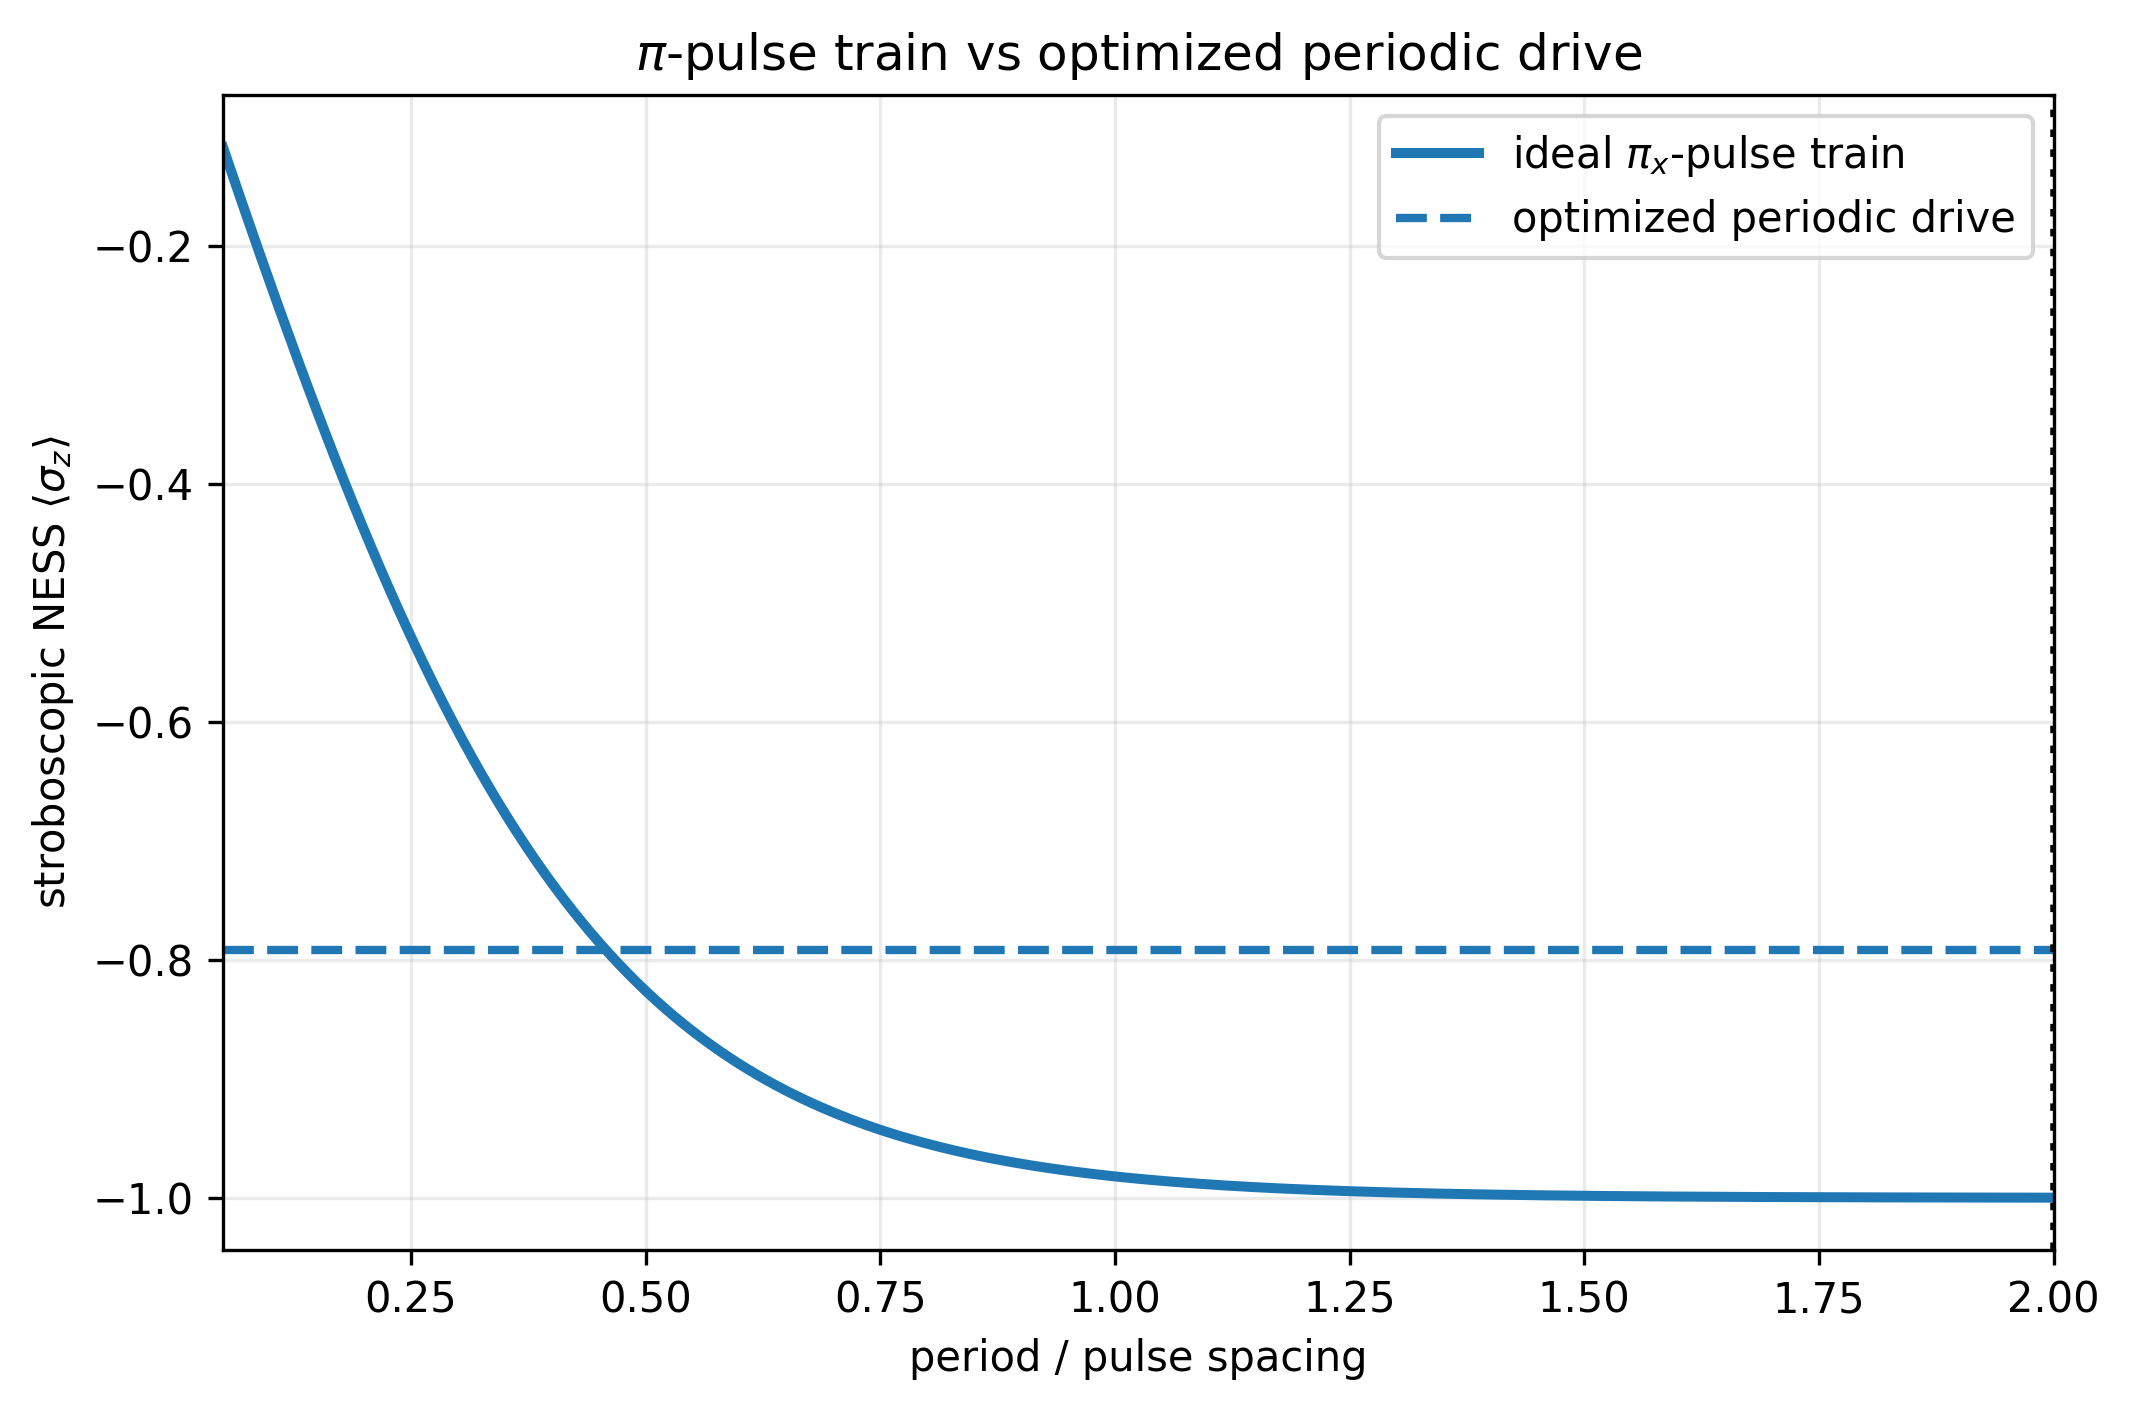

In [5]:
# ============================================================
# Compare optimized periodic drive vs repeated ideal pi-pulse train
# Same dissipative model, same allowed period window T_bounds
# Stroboscopic NESS is sampled immediately AFTER each pi pulse
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.optimize import minimize_scalar
from scipy.linalg import lu_factor, lu_solve

# ---------- helper: free-relaxation one-period map ----------
H_free = 0.0 * sx_q  # no drive between pulses

def free_relax_map_mesolve(tau: float) -> np.ndarray:
    """
    One-period superoperator for free open-system relaxation over time tau.
    """
    tlist = [0.0, float(tau)]
    cols = []
    for rho0 in BASIS_RHOS:
        res = qt.mesolve(H_free, rho0, tlist, c_ops=c_ops, e_ops=None, options=opts)
        rho_tau = res.states[-1].full()
        cols.append(vec(rho_tau))
    return np.column_stack(cols)

# ---------- helper: instantaneous pi_x pulse map ----------
# U_pi = exp(-i pi sigma_x / 2) = -i sigma_x  (global phase irrelevant)
U_pi = -1j * sx_q

def pi_pulse_map() -> np.ndarray:
    cols = []
    for rho0 in BASIS_RHOS:
        rho1 = U_pi * rho0 * U_pi.dag()
        cols.append(vec(rho1.full()))
    return np.column_stack(cols)

P_pi = pi_pulse_map()

# ---------- cycle map: state just after pulse -> relax -> next pulse ----------
def stroboscopic_sz_pi_train(tau: float):
    """
    Returns:
      z_post : <sigma_z> in the stroboscopic NESS immediately AFTER the pi pulse
      z_pre  : <sigma_z> immediately BEFORE the pi pulse
      r_post : vectorized NESS state immediately AFTER the pi pulse
    """
    F_tau = free_relax_map_mesolve(tau)

    # after-pulse -> free relax -> next pulse -> after-pulse
    Phi_pi = P_pi @ F_tau

    A, b = ness_augmented_system(Phi_pi)
    LU = lu_factor(A)
    x = lu_solve(LU, b)
    r_post = x[:4]                  # NESS sampled just after pulse
    r_pre = F_tau @ r_post          # same NESS sampled just before next pulse

    z_post = float(np.real((vec(sz).conj().T @ r_post).item()))
    z_pre  = float(np.real((vec(sz).conj().T @ r_pre ).item()))
    return z_post, z_pre, r_post

def obj_pi_train(tau: float) -> float:
    z_post, _, _ = stroboscopic_sz_pi_train(tau)
    return z_post   # minimize <sigma_z> to maximize excited-state population

# ---------- optimize pulse spacing over same allowed window as Fourier protocol ----------
res_pi = minimize_scalar(
    obj_pi_train,
    bounds=(float(T_bounds[0]), float(T_bounds[1])),
    method="bounded",
    options={"xatol": 1e-4}
)

tau_pi_best = float(res_pi.x)
sz_pi_post_best, sz_pi_pre_best, r_pi_post_best = stroboscopic_sz_pi_train(tau_pi_best)

# Excited-state populations
pe_pi_post_best = 0.5 * (1.0 - sz_pi_post_best)
pe_pi_pre_best  = 0.5 * (1.0 - sz_pi_pre_best)

# Optimized periodic-drive result from the notebook
# sz_star was already computed above as the optimized Floquet-NESS value
sz_fourier_best = float(sz_star)
pe_fourier_best = 0.5 * (1.0 - sz_fourier_best)

print("\n================ PI-PULSE vs OPTIMIZED PERIODIC DRIVE ================\n")
print("Optimized periodic drive:")
print(f"  T_best                = {T_best:.6f}")
print(f"  <sigma_z>_NESS        = {sz_fourier_best:.6f}")
print(f"  excited population    = {pe_fourier_best:.6f}")

print("\nRepeated ideal pi-pulse train (sampled just AFTER each pulse):")
print(f"  tau_pi_best           = {tau_pi_best:.6f}")
print(f"  <sigma_z>_post        = {sz_pi_post_best:.6f}")
print(f"  excited population    = {pe_pi_post_best:.6f}")

print("\nSame pi-pulse train (sampled just BEFORE each pulse):")
print(f"  <sigma_z>_pre         = {sz_pi_pre_best:.6f}")
print(f"  excited population    = {pe_pi_pre_best:.6f}")

if sz_pi_post_best < sz_fourier_best:
    print("\nResult: ideal pi-pulse train gives a lower stroboscopic <sigma_z> "
          "(higher excited-state population) than the optimized Fourier drive "
          "within the same allowed period window.")
else:
    print("\nResult: optimized Fourier periodic drive beats the ideal pi-pulse train "
          "for stroboscopic NESS preparation within the same allowed period window.")

# ---------- optional scan + comparison plot ----------
tau_grid = np.linspace(float(T_bounds[0]), float(T_bounds[1]), 200)
sz_pi_post_grid = np.array([stroboscopic_sz_pi_train(tau)[0] for tau in tau_grid], dtype=float)

plt.figure(figsize=(7.2, 4.8), dpi=300)
plt.plot(tau_grid, sz_pi_post_grid, lw=2.4, label=r'ideal $\pi_x$-pulse train')
plt.axhline(sz_fourier_best, ls='--', lw=2.0, label='optimized periodic drive')
plt.axvline(tau_pi_best, ls=':', lw=1.8, color='k')

plt.xlabel(r'period / pulse spacing')
plt.ylabel(r'stroboscopic NESS $\langle \sigma_z \rangle$')
plt.title(r'$\pi$-pulse train vs optimized periodic drive')
plt.xlim(float(T_bounds[0]), float(T_bounds[1]))
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()